# LLM TTS — GPT-2 + FocalCodec

Лабораторна робота №4. Імплементація моделі генерації мовлення на основі мовної моделі GPT-2 та аудіо-кодеку FocalCodec, з тренуванням на датасеті LJ Speech.

In [3]:
!pip install -q focalcodec@git+https://github.com/lucadellalib/focalcodec.git@main#egg=focalcodec
!pip install -q pytorch_lightning jiwer speechbrain

  Preparing metadata (setup.py) ... done


In [4]:
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

Mounted at /content/drive/


## 1. Датасет — LJ Speech

In [5]:
import os
from pathlib import Path
import torchaudio

data_dir = "./data"
os.makedirs(data_dir, exist_ok=True)

kaggle_path = Path("/kaggle/input/datasets/mathurinache/the-lj-speech-dataset/LJSpeech-1.1")
if kaggle_path.exists():
    dataset_root = "/kaggle/input/datasets/mathurinache/the-lj-speech-dataset"
    ljspeech = torchaudio.datasets.LJSPEECH(root=dataset_root, download=False)
else:
    ljspeech = torchaudio.datasets.LJSPEECH(root=data_dir, download=True)
    dataset_root = data_dir

waveform, sr, transcript, transcript_norm = ljspeech[0]
print("dataset root:", dataset_root)
print("waveform:", waveform.shape, " sample rate:", sr)
print("transcript:", transcript)

100%|██████████| 2.56G/2.56G [00:13<00:00, 198MB/s]


dataset root: ./data
waveform: torch.Size([1, 212893])  sample rate: 22050
transcript: Printing, in the only sense with which we are at present concerned, differs from most if not from all the arts and crafts represented in the Exhibition


In [6]:
import pandas as pd
import numpy as np

candidates = [
    Path(dataset_root) / "LJSpeech-1.1" / "metadata.csv",
    Path("./LJSpeech-1.1") / "metadata.csv",
]
meta_path = next((p for p in candidates if p.exists()), None)
assert meta_path is not None, "metadata.csv not found"

wav_dir = meta_path.parent / "wavs"
meta = pd.read_csv(meta_path, sep='|', header=None, names=['id', 'text', 'text_norm'])
meta['text_norm'] = meta['text_norm'].fillna(meta['text'])
meta['filepath'] = meta['id'].apply(lambda s: str(wav_dir / f'{s}.wav'))

rng = np.random.default_rng(42)
perm = rng.permutation(len(meta))
split_at = int(0.9 * len(meta))
train_df = meta.iloc[perm[:split_at]].reset_index(drop=True)
val_df = meta.iloc[perm[split_at:]].reset_index(drop=True)
print(f'train: {len(train_df)}  val: {len(val_df)}')
train_df.head(2)

train: 11790  val: 1310


,id,text,text_norm,filepath
0,LJ022-0092,and such projects as they approve will be next...,and such projects as they approve will be next...,data/LJSpeech-1.1/wavs/LJ022-0092.wav
1,LJ039-0028,"was shipped from Los Angeles on March 20, 1963...","was shipped from Los Angeles on March twenty, ...",data/LJSpeech-1.1/wavs/LJ039-0028.wav


## 2. Аудіо-кодек FocalCodec

In [7]:
from focalcodec import FocalCodec
import torch
import librosa
import matplotlib.pyplot as plt
import soundfile as sf

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/577M [00:00<?, ?B/s]

codebook size: 8192, sr in/out: 16000/16000
LJ003-0083: 6.50s -> 162 tokens


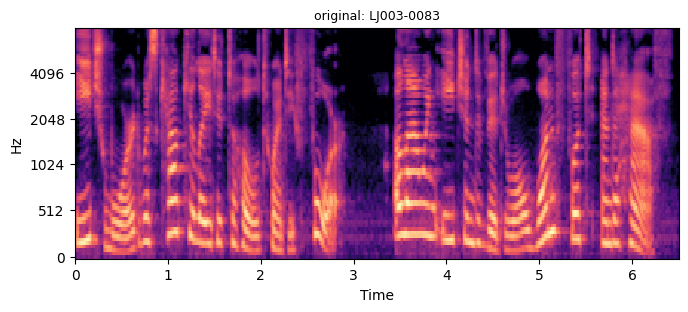

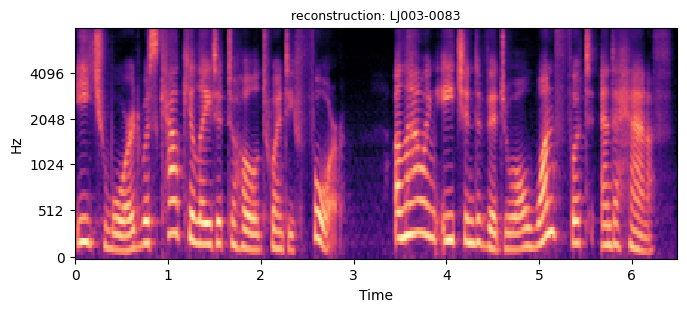

In [8]:
codec = FocalCodec.from_pretrained('lucadellalib/focalcodec_25hz').to(device).eval()
for p in codec.parameters():
    p.requires_grad_(False)

codebook_size = int(codec.codebook.shape[0])
codec_sr = codec.sample_rate_input
print(f'codebook size: {codebook_size}, sr in/out: {codec_sr}/{codec.sample_rate_output}')


def read_wav_16k(path):
    arr, sr = sf.read(path, dtype='float32', always_2d=False)
    if arr.ndim > 1:
        arr = arr.mean(-1)
    wav = torch.from_numpy(arr)
    if sr != codec_sr:
        wav = torchaudio.functional.resample(wav, sr, codec_sr)
    return wav


def show_mel(wav, sr, title=''):
    wav = np.asarray(wav).astype(np.float32)
    if wav.ndim > 1:
        wav = wav.mean(0)
    S = librosa.feature.melspectrogram(
        y=wav, sr=sr, n_fft=1024, hop_length=256,
        n_mels=80, fmin=50, fmax=sr // 2,
    )
    fig, ax = plt.subplots(figsize=(max(6, len(wav) / sr * 1.2), 3))
    librosa.display.specshow(
        librosa.power_to_db(S, ref=np.max), sr=sr, hop_length=256,
        x_axis='time', y_axis='mel', ax=ax,
    )
    ax.set_title(title, fontsize=9)
    plt.show()


row = val_df.iloc[0]
wav = read_wav_16k(row['filepath']).to(device)
with torch.no_grad():
    toks = codec.sig_to_toks(wav.unsqueeze(0))
    rec = codec.toks_to_sig(toks).squeeze(0).cpu().numpy()
print(f'{row["id"]}: {wav.shape[-1] / codec_sr:.2f}s -> {toks.shape[-1]} tokens')
show_mel(wav.cpu().numpy(), codec_sr, f'original: {row["id"]}')
show_mel(rec, codec.sample_rate_output, f'reconstruction: {row["id"]}')

## 3. Попередня обробка та кешування

In [9]:
from tqdm.auto import tqdm
from transformers import GPT2TokenizerFast

tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')

cache_dir = os.path.join(data_dir, 'tokenized')
os.makedirs(cache_dir, exist_ok=True)
train_cache = os.path.join(cache_dir, 'train.pt')
val_cache = os.path.join(cache_dir, 'val.pt')

lang_prefix = "English:"


@torch.no_grad()
def precompute_tokens(df, cache_path, batch_size=16, overwrite=False):
    if os.path.exists(cache_path) and not overwrite:
        print(f'cache exists, loading: {cache_path}')
        return torch.load(cache_path, weights_only=False)

    records = df.to_dict('records')
    paths = [r['filepath'] for r in records]
    # сортування за розміром файлу для меншого padding-у в батчах
    order = np.argsort([os.path.getsize(p) for p in paths])
    result = [None] * len(records)

    for start in tqdm(range(0, len(records), batch_size), desc=os.path.basename(cache_path)):
        idxs = order[start:start + batch_size]
        wavs = [read_wav_16k(paths[i]) for i in idxs]

        lens = torch.tensor([w.numel() for w in wavs], dtype=torch.float32)
        Lmax = int(lens.max())
        batch = torch.zeros(len(wavs), Lmax)
        for j, w in enumerate(wavs):
            batch[j, :w.numel()] = w

        batch = batch.to(device)
        len_ratio = (lens / Lmax).to(device)
        toks = codec.sig_to_toks(batch, length=len_ratio)
        tok_lens = (len_ratio * toks.shape[-1]).round().clamp(max=toks.shape[-1]).long()

        for j, i in enumerate(idxs):
            full_text = f"{lang_prefix} {records[i]['text_norm']}"
            text_ids = tokenizer.encode(full_text, add_special_tokens=False)
            text_ids = torch.tensor(text_ids, dtype=torch.long)
            audio_ids = toks[j, :tok_lens[j]].long().cpu()
            result[i] = {
                'id': records[i]['id'],
                'text': records[i]['text_norm'],
                'text_ids': text_ids,
                'audio_ids': audio_ids,
                'n_text': int(text_ids.numel()),
                'n_audio': int(audio_ids.numel()),
            }

    torch.save(result, cache_path)
    print(f'saved {len(result)} items to {cache_path}')
    return result


print('precompute train')
train_items = precompute_tokens(train_df, train_cache)
print('precompute val')
val_items = precompute_tokens(val_df, val_cache)

n_audio = np.array([r['n_audio'] for r in train_items])
n_text = np.array([r['n_text'] for r in train_items])
print(f'audio tokens: mean={n_audio.mean():.1f}  p95={np.percentile(n_audio, 95):.0f}  max={n_audio.max()}')
print(f'text  tokens: mean={n_text.mean():.1f}  p95={np.percentile(n_text, 95):.0f}  max={n_text.max()}')

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

precompute train


train.pt:   0%|          | 0/737 [00:00<?, ?it/s]

saved 11790 items to ./data/tokenized/train.pt
precompute val


val.pt:   0%|          | 0/82 [00:00<?, ?it/s]

saved 1310 items to ./data/tokenized/val.pt
audio tokens: mean=164.7  p95=244  max=252
text  tokens: mean=22.7  p95=34  max=71


In [10]:
from torch.utils.data import Dataset, DataLoader


class LJSpeechTokens(Dataset):
    def __init__(self, cache_path, max_len=1024):
        items = torch.load(cache_path, weights_only=False)
        self.items = [x for x in items if x['n_text'] + x['n_audio'] + 2 <= max_len]

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        x = self.items[idx]
        return {
            'id': x['id'],
            'text_ids': x['text_ids'].long(),
            'audio_ids': x['audio_ids'].long(),
        }


def pad_collate(batch):
    B = len(batch)
    text_lens = torch.tensor([b['text_ids'].numel() for b in batch], dtype=torch.long)
    audio_lens = torch.tensor([b['audio_ids'].numel() for b in batch], dtype=torch.long)
    text_ids = torch.zeros(B, int(text_lens.max()), dtype=torch.long)
    audio_ids = torch.zeros(B, int(audio_lens.max()), dtype=torch.long)
    for i, b in enumerate(batch):
        text_ids[i, :b['text_ids'].numel()] = b['text_ids']
        audio_ids[i, :b['audio_ids'].numel()] = b['audio_ids']
    return {
        'text_ids': text_ids, 'text_lens': text_lens,
        'audio_ids': audio_ids, 'audio_lens': audio_lens,
    }


train_ds = LJSpeechTokens(train_cache)
val_ds = LJSpeechTokens(val_cache)
print(f'after filter: train={len(train_ds)} val={len(val_ds)}')

dl = DataLoader(train_ds, batch_size=2, collate_fn=pad_collate)
sample = next(iter(dl))
for k, v in sample.items():
    print(k, v.shape)

after filter: train=11790 val=1310
text_ids torch.Size([2, 33])
text_lens torch.Size([2])
audio_ids torch.Size([2, 244])
audio_lens torch.Size([2])


## 4. Архітектура моделі GPT2TTS

In [11]:
from dataclasses import dataclass
import torch.nn as nn
import torch.nn.functional as F
from transformers import GPT2LMHeadModel


@dataclass
class GPT2TTSConfig:
    base_model: str = 'gpt2'
    codebook_size: int = 8192
    n_special: int = 2

    @property
    def vocab_size(self):
        return self.codebook_size + self.n_special

    @property
    def bos_id(self):
        return self.codebook_size

    @property
    def eos_id(self):
        return self.codebook_size + 1


class GPT2TTS(nn.Module):
    def __init__(self, cfg: GPT2TTSConfig):
        super().__init__()
        self.cfg = cfg
        self.gpt = GPT2LMHeadModel.from_pretrained(cfg.base_model)
        H = self.gpt.config.n_embd
        V = cfg.vocab_size

        self.audio_emb = nn.Embedding(V, H)
        self.audio_head = nn.Linear(H, V, bias=False)
        nn.init.normal_(self.audio_emb.weight, std=0.02)
        nn.init.normal_(self.audio_head.weight, std=0.02)

    def _pack_batch(self, text_ids, text_lens, audio_ids, audio_lens):
        B = text_ids.size(0)
        H = self.gpt.config.n_embd
        L = int((text_lens + audio_lens + 2).max().item())
        dev = text_ids.device

        inputs = torch.zeros(B, L, H, device=dev, dtype=self.gpt.transformer.wte.weight.dtype)
        attn = torch.zeros(B, L, device=dev, dtype=torch.long)
        labels = torch.full((B, L), -100, device=dev, dtype=torch.long)

        for i in range(B):
            tl = int(text_lens[i].item())
            al = int(audio_lens[i].item())

            if tl > 0:
                inputs[i, :tl] = self.gpt.transformer.wte(text_ids[i, :tl])
                attn[i, :tl] = 1

            bos_pos = tl
            inputs[i, bos_pos] = self.audio_emb.weight[self.cfg.bos_id]
            attn[i, bos_pos] = 1

            a_start = tl + 1
            a_end = a_start + al
            if al > 0:
                a_tokens = audio_ids[i, :al]
                inputs[i, a_start:a_end] = self.audio_emb(a_tokens)
                attn[i, a_start:a_end] = 1
                labels[i, a_start:a_end] = a_tokens

            eos_pos = a_end
            inputs[i, eos_pos] = self.audio_emb.weight[self.cfg.eos_id]
            attn[i, eos_pos] = 1
            labels[i, eos_pos] = self.cfg.eos_id

        return inputs, attn, labels

    def forward(self, text_ids, text_lens, audio_ids, audio_lens):
        inputs, attn, labels = self._pack_batch(text_ids, text_lens, audio_ids, audio_lens)
        hidden = self.gpt.transformer(
            inputs_embeds=inputs,
            attention_mask=attn,
            return_dict=True,
        ).last_hidden_state
        logits = self.audio_head(hidden)

        shift_logits = logits[:, :-1, :].float().contiguous()
        shift_labels = labels[:, 1:].contiguous()
        loss = F.cross_entropy(
            shift_logits.view(-1, shift_logits.size(-1)),
            shift_labels.view(-1),
            ignore_index=-100,
        )
        return {'loss': loss, 'logits': logits}

    @torch.no_grad()
    def generate_audio(
        self,
        text_ids,
        max_new_tokens=500,
        temperature=0.9,
        top_k=50,
        top_p=1.0,
        do_sample=True,
    ):
        self.eval()
        dev = text_ids.device
        text_ids = text_ids.view(-1).long().to(dev)

        text_emb = self.gpt.transformer.wte(text_ids).unsqueeze(0)
        bos_emb = self.audio_emb.weight[self.cfg.bos_id].view(1, 1, -1)
        prefix = torch.cat([text_emb, bos_emb], dim=1)
        attn = torch.ones(1, prefix.size(1), device=dev, dtype=torch.long)

        out = self.gpt.transformer(
            inputs_embeds=prefix,
            attention_mask=attn,
            use_cache=True,
            return_dict=True,
        )
        kv_cache = out.past_key_values
        h = out.last_hidden_state[:, -1, :]

        generated = []
        for _ in range(max_new_tokens):
            logits = self.audio_head(h)

            if not do_sample or temperature <= 0:
                next_id = torch.argmax(logits, dim=-1)
            else:
                logits = logits / max(temperature, 1e-5)

                if top_k is not None and top_k > 0:
                    k = min(int(top_k), logits.size(-1))
                    vals, _ = torch.topk(logits, k)
                    threshold = vals[:, -1].unsqueeze(-1)
                    logits = logits.masked_fill(logits < threshold, float('-inf'))

                if top_p is not None and 0 < top_p < 1.0:
                    sorted_logits, sorted_idx = torch.sort(logits, descending=True, dim=-1)
                    probs_sorted = torch.softmax(sorted_logits, dim=-1)
                    cumsum = torch.cumsum(probs_sorted, dim=-1)
                    remove = cumsum > top_p
                    remove[..., 1:] = remove[..., :-1].clone()
                    remove[..., 0] = False
                    sorted_logits = sorted_logits.masked_fill(remove, float('-inf'))
                    logits = torch.full_like(logits, float('-inf'))
                    logits.scatter_(1, sorted_idx, sorted_logits)

                probs = torch.softmax(logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1).squeeze(-1)

            tok = int(next_id.item())
            if tok == self.cfg.eos_id:
                break
            generated.append(tok)

            attn = torch.cat([attn, torch.ones(1, 1, device=dev, dtype=torch.long)], dim=1)
            new_emb = self.audio_emb(next_id).unsqueeze(1)
            out = self.gpt.transformer(
                inputs_embeds=new_emb,
                attention_mask=attn,
                past_key_values=kv_cache,
                use_cache=True,
                return_dict=True,
            )
            kv_cache = out.past_key_values
            h = out.last_hidden_state[:, -1, :]

        return torch.tensor(generated, dtype=torch.long, device=dev)

In [12]:
cfg = GPT2TTSConfig(codebook_size=codebook_size)
model = GPT2TTS(cfg).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'TTS model: {n_params/1e6:.1f}M params')

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

TTS model: 137.0M params


## 5. Тренувальний пайплайн (PyTorch Lightning)

In [15]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor


class TTSDataModule(pl.LightningDataModule):
    def __init__(self, train_cache, val_cache, batch_size=32, num_workers=2, max_len=1024):
        super().__init__()
        self.train_cache = train_cache
        self.val_cache = val_cache
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.max_len = max_len

    def setup(self, stage=None):
        self.train_ds = LJSpeechTokens(self.train_cache, max_len=self.max_len)
        self.val_ds = LJSpeechTokens(self.val_cache, max_len=self.max_len)

    def train_dataloader(self):
        return DataLoader(
            self.train_ds, batch_size=self.batch_size, shuffle=True,
            num_workers=self.num_workers, pin_memory=torch.cuda.is_available(),
            collate_fn=pad_collate,
        )

    def val_dataloader(self):
        return DataLoader(
            self.val_ds, batch_size=self.batch_size, shuffle=False,
            num_workers=self.num_workers, pin_memory=torch.cuda.is_available(),
            collate_fn=pad_collate,
        )


class LitTTS(pl.LightningModule):
    def __init__(self, cfg: GPT2TTSConfig, lr=2e-4, weight_decay=0.01, warmup_steps=500):
        super().__init__()
        self.save_hyperparameters(ignore=['cfg'])
        self.model = GPT2TTS(cfg)

    def training_step(self, batch, batch_idx):
        out = self.model(**batch)
        self.log('train_loss', out['loss'], prog_bar=True, on_step=True, on_epoch=True,
                 batch_size=batch['text_ids'].size(0))
        return out['loss']

    def validation_step(self, batch, batch_idx):
        out = self.model(**batch)
        self.log('val_loss', out['loss'], prog_bar=True, on_step=False, on_epoch=True,
                 batch_size=batch['text_ids'].size(0))

    def configure_optimizers(self):
        opt = torch.optim.AdamW(
            self.parameters(),
            lr=self.hparams.lr,
            weight_decay=self.hparams.weight_decay,
        )

        def lr_fn(step):
            w = max(1, int(self.hparams.warmup_steps))
            if step < w:
                return (step + 1) / w
            return 1.0

        sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_fn)
        return {
            'optimizer': opt,
            'lr_scheduler': {'scheduler': sched, 'interval': 'step'},
        }


pl.seed_everything(42, workers=True)

batch_size = 32 if torch.cuda.is_available() else 2
dm = TTSDataModule(train_cache, val_cache, batch_size=batch_size, num_workers=2)

lit_model = LitTTS(cfg, lr=2e-4, weight_decay=0.01, warmup_steps=500)
ckpt_dir = os.path.join(data_dir, 'checkpoints')
os.makedirs(ckpt_dir, exist_ok=True)

callbacks = [
    ModelCheckpoint(
        dirpath=ckpt_dir,
        filename='tts-{epoch:02d}-{val_loss:.3f}',
        monitor='val_loss', mode='min',
        save_top_k=1, save_last=True,
    ),
    LearningRateMonitor(logging_interval='step'),
]

trainer = pl.Trainer(
    max_epochs=15,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    precision='bf16-mixed',
    gradient_clip_val=1.0,
    accumulate_grad_batches=1,
    log_every_n_steps=20,
    callbacks=callbacks,
)

resume_from = "/content/drive/MyDrive/KPI/gpt2_lightning_grad.ckpt"
if os.path.exists(resume_from):
    print(f'resuming from: {resume_from}')
    trainer.fit(lit_model, datamodule=dm, ckpt_path=resume_from)
else:
    trainer.fit(lit_model, datamodule=dm)

INFO:lightning_fabric.utilities.seed:Seed set to 42


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
INFO:pytorch_lightning.utilities.rank_zero:Using bfloat16 Automatic Mixed Precision (AMP)
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_prec

┏━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GPT2TTS │  137 M │ train │     0 │
└───┴───────┴─────────┴────────┴───────┴───────┘

Trainable params: 137 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 137 M                                                                                                
Total estimated model params size (MB): 548                                                                        
Modules in train mode: 3                                                                                           
Modules in eval mode: 164                                                                                          
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:534: Found 164 module(s) in eval mode 
at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can 
ignore this warning.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


In [16]:
save_to = "/content/drive/MyDrive/KPI/gpt2_lightning_grad.ckpt"
trainer.save_checkpoint(save_to)
print(f'saved checkpoint: {save_to}')

INFO:pytorch_lightning.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


saved checkpoint: /content/drive/MyDrive/KPI/gpt2_lightning_grad.ckpt


## 6. Інференс з різними стратегіями семплування

[        greedy] tokens=  69  sec= 2.76  "The quick brown fox jumps over the lazy dog."


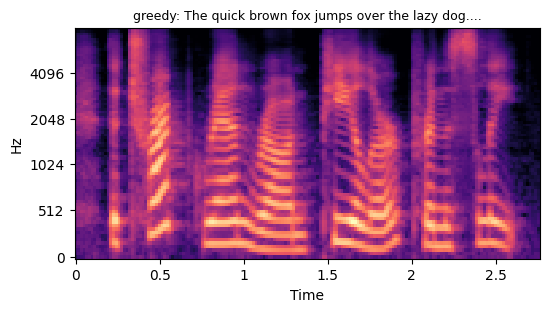

[      top_k_50] tokens=  75  sec= 3.00  "The quick brown fox jumps over the lazy dog."


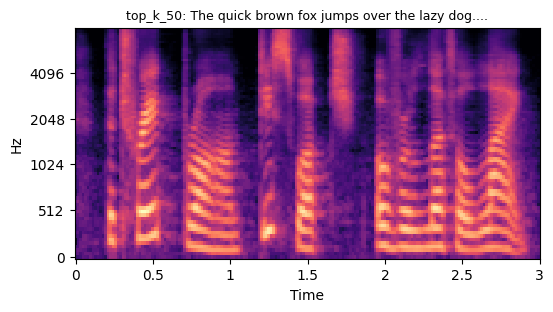

[   nucleus_p90] tokens=  74  sec= 2.96  "The quick brown fox jumps over the lazy dog."


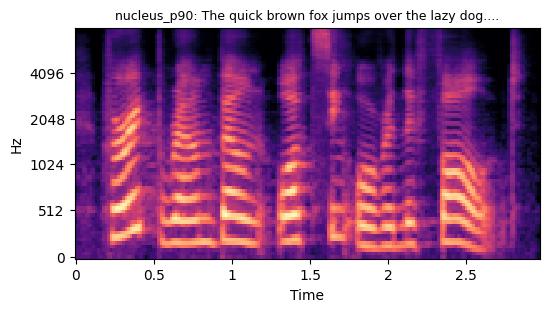

[ top_k_100_p95] tokens=  79  sec= 3.16  "The quick brown fox jumps over the lazy dog."


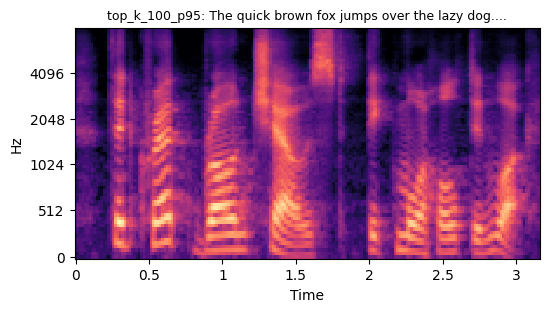

[        greedy] tokens= 147  sec= 5.88  "Each ward was calculated to hold twenty-four, allowing "


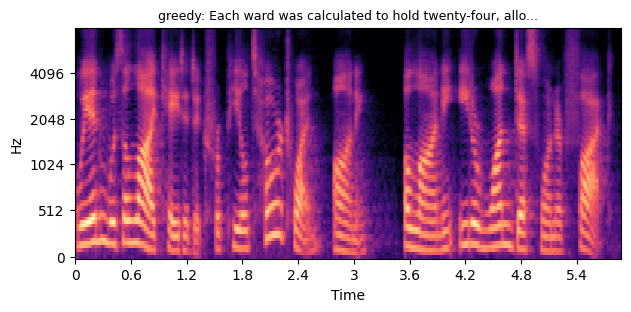

[      top_k_50] tokens= 161  sec= 6.44  "Each ward was calculated to hold twenty-four, allowing "


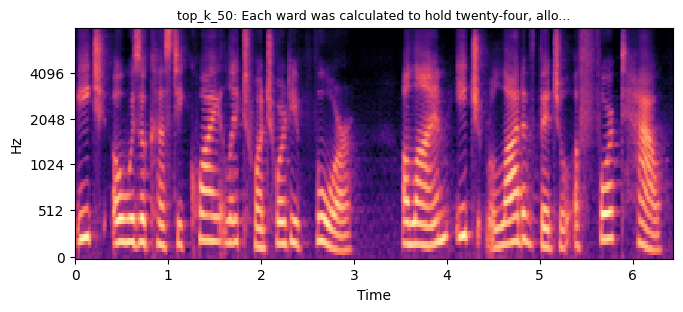

[   nucleus_p90] tokens= 145  sec= 5.80  "Each ward was calculated to hold twenty-four, allowing "


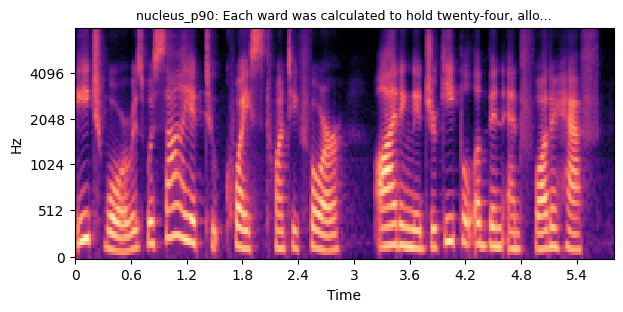

[ top_k_100_p95] tokens= 158  sec= 6.32  "Each ward was calculated to hold twenty-four, allowing "


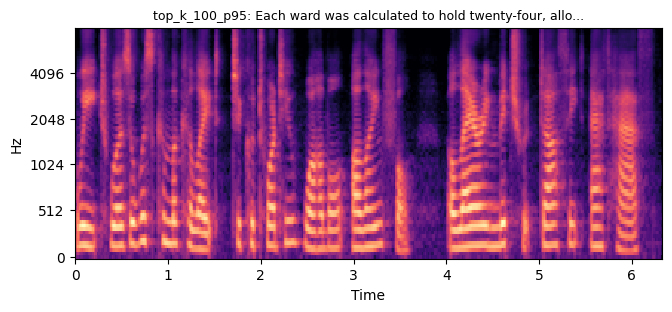

[        greedy] tokens= 161  sec= 6.44  "Much of the Secret Service work requires the developmen"


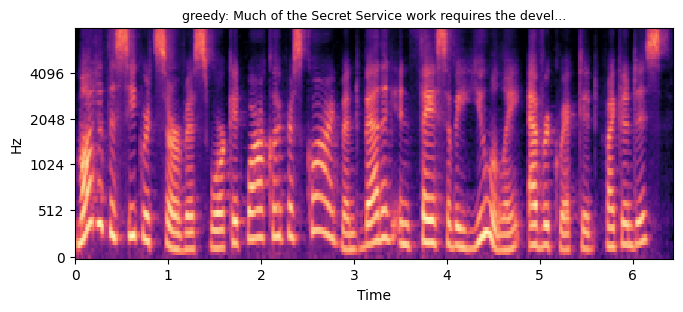

[      top_k_50] tokens= 156  sec= 6.24  "Much of the Secret Service work requires the developmen"


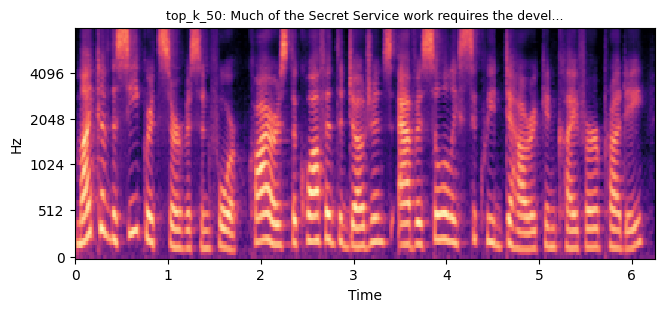

[   nucleus_p90] tokens= 160  sec= 6.40  "Much of the Secret Service work requires the developmen"


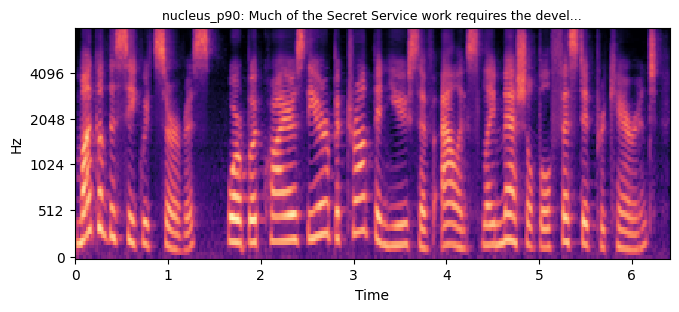

[ top_k_100_p95] tokens= 154  sec= 6.16  "Much of the Secret Service work requires the developmen"


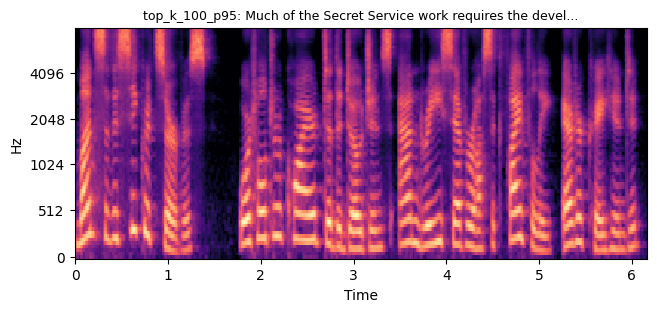

In [17]:
from IPython.display import display, Audio

load_ckpt = None
if load_ckpt and os.path.exists(load_ckpt):
    lit_model = LitTTS.load_from_checkpoint(load_ckpt, cfg=cfg)

tts_model = lit_model.model.to(device).eval()


def synthesize(text, max_new=500, temperature=0.9, top_k=50, top_p=1.0, do_sample=True):
    full = f"{lang_prefix} {text}"
    text_ids = torch.tensor(tokenizer.encode(full, add_special_tokens=False), device=device)
    toks = tts_model.generate_audio(
        text_ids,
        max_new_tokens=max_new,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        do_sample=do_sample,
    )
    if toks.numel() == 0:
        return np.zeros(codec_sr // 2, dtype=np.float32), toks
    with torch.no_grad():
        wav = codec.toks_to_sig(toks.unsqueeze(0)).squeeze(0).cpu().numpy().astype(np.float32)
    return wav, toks


sampling_setups = {
    'greedy':        dict(do_sample=False, temperature=0.0, top_k=0,   top_p=1.0),
    'top_k_50':      dict(do_sample=True,  temperature=0.9, top_k=50,  top_p=1.0),
    'nucleus_p90':   dict(do_sample=True,  temperature=0.9, top_k=0,   top_p=0.90),
    'top_k_100_p95': dict(do_sample=True,  temperature=0.8, top_k=100, top_p=0.95),
}

test_texts = [
    "The quick brown fox jumps over the lazy dog.",
    "Each ward was calculated to hold twenty-four, allowing each individual one foot and a half",
    "Much of the Secret Service work requires the development and use of highly sophisticated equipment",
]

demo_results = []
for text in test_texts:
    for name, params in sampling_setups.items():
        wav, toks = synthesize(text, max_new=500, **params)
        dur = wav.shape[-1] / codec_sr
        print(f'[{name:>14s}] tokens={toks.numel():4d}  sec={dur:5.2f}  "{text[:55]}"')
        show_mel(wav, codec_sr, f'{name}: {text[:50]}...')
        display(Audio(wav, rate=codec_sr))
        demo_results.append({'text': text, 'sampling': name, 'wav': wav, 'tokens': toks.cpu().numpy()})

## 7. Метрики з xTTS статті: CER, UTMOS, SECS

In [23]:
def levenshtein_cer(ref, hyp):
    r, h = list(ref), list(hyp)
    dp = [[0] * (len(h) + 1) for _ in range(len(r) + 1)]
    for i in range(len(r) + 1):
        dp[i][0] = i
    for j in range(len(h) + 1):
        dp[0][j] = j
    for i in range(1, len(r) + 1):
        for j in range(1, len(h) + 1):
            cost = 0 if r[i - 1] == h[j - 1] else 1
            dp[i][j] = min(dp[i - 1][j] + 1, dp[i][j - 1] + 1, dp[i - 1][j - 1] + cost)
    return dp[-1][-1] / max(1, len(r))


try:
    from jiwer import cer as jiwer_cer
except Exception:
    jiwer_cer = None


def compute_cer(ref, hyp):
    if jiwer_cer is not None:
        return float(jiwer_cer(ref, hyp))
    return float(levenshtein_cer(ref, hyp))


_asr_processor = None
_asr_model = None

def get_asr():
    global _asr_processor, _asr_model
    if _asr_model is None:
        from transformers import WhisperProcessor, WhisperForConditionalGeneration
        _asr_processor = WhisperProcessor.from_pretrained('openai/whisper-small.en')
        _asr_model = WhisperForConditionalGeneration.from_pretrained('openai/whisper-small.en')
        _asr_model = _asr_model.to(device).eval()
    return _asr_processor, _asr_model


_spk = None

def get_speaker_model():
    global _spk
    if _spk is None:
        from speechbrain.inference.speaker import EncoderClassifier
        _spk = EncoderClassifier.from_hparams(
            source='speechbrain/spkrec-ecapa-voxceleb',
            run_opts={'device': str(device)},
        )
    return _spk


_utmos = None

def get_utmos():
    global _utmos
    if _utmos is not None:
        return _utmos
    try:
        _utmos = torch.hub.load('tarepan/SpeechMOS:v1.2.0', 'utmos22_strong', trust_repo=True)
        _utmos = _utmos.to(device).eval()
        return _utmos
    except Exception as e:
        print('UTMOS load failed:', e)
        return None


def to_16k(wav_np, sr):
    w = torch.tensor(wav_np, dtype=torch.float32)
    if w.ndim > 1:
        w = w.mean(0)
    if sr != 16000:
        w = torchaudio.functional.resample(w, sr, 16000)
    return w


def transcribe(wav_np, sr):
    processor, asr_model = get_asr()
    wav16 = to_16k(wav_np, sr).cpu().numpy().astype(np.float32)
    inputs = processor(wav16, sampling_rate=16000, return_tensors='pt')
    input_features = inputs.input_features.to(device)
    with torch.no_grad():
        predicted_ids = asr_model.generate(input_features, max_new_tokens=200)
    text = processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]
    return text.strip()

def speaker_emb(wav_np, sr):
    m = get_speaker_model()
    w = to_16k(wav_np, sr).unsqueeze(0).to(device)
    with torch.no_grad():
        e = m.encode_batch(w).squeeze(0).squeeze(0)
    return F.normalize(e.float(), dim=-1)


def compute_utmos(wav_np, sr):
    m = get_utmos()
    if m is None:
        return float('nan')
    w = to_16k(wav_np, sr).unsqueeze(0).to(device)
    with torch.no_grad():
        for call in [
            lambda: m(w, 16000),
            lambda: m(w),
            lambda: m({'wav': w, 'sample_rate': 16000}),
        ]:
            try:
                s = call()
                if torch.is_tensor(s):
                    return float(s.mean().item())
                return float(s)
            except Exception:
                continue
    return float('nan')

In [24]:
def evaluate(df, n=8, sampling='greedy'):
    rows = []
    params = sampling_setups[sampling]

    for i in range(min(n, len(df))):
        row = df.iloc[i]
        ref = row['text_norm']

        gen_wav, gen_toks = synthesize(ref, max_new=500, **params)
        hyp = transcribe(gen_wav, codec_sr)
        cer = compute_cer(ref.lower(), hyp.lower())

        ref_wav = read_wav_16k(row['filepath']).cpu().numpy()
        e_gen = speaker_emb(gen_wav, codec_sr)
        e_ref = speaker_emb(ref_wav, codec_sr)
        secs = float(F.cosine_similarity(e_gen, e_ref, dim=0).item())

        utmos = compute_utmos(gen_wav, codec_sr)

        print(f'\nREF: {ref}')
        print(f'ASR: {hyp}')

        rows.append({
            'id': row['id'],
            'sampling': sampling,
            'ref_text': ref,
            'asr_text': hyp,
            'CER': cer,
            'UTMOS': utmos,
            'SECS': secs,
            'n_tokens': int(gen_toks.numel()),
        })

    df_out = pd.DataFrame(rows)
    summary = df_out[['CER', 'UTMOS', 'SECS', 'n_tokens']].mean(numeric_only=True)
    return df_out, summary


n_eval = 8
all_summaries = {}
all_dfs = {}

for name in sampling_setups.keys():
    print(f'\n========== {name} ==========')
    df_m, summ = evaluate(val_df, n=n_eval, sampling=name)
    all_dfs[name] = df_m
    all_summaries[name] = summ
    print(summ)


========== greedy ==========


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformer

hyperparams.yaml: 0.00B [00:00, ?B/s]

INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/spkrec-ecapa-voxceleb' if not cached


...


REF: and he was therefore prepared to submit to Parliament a proposal that half the cost of reconstruction should be borne by public funds.
ASR: and he was overpaid to permit minutes to carpools of the Rupo pose that has a short distribute trimmed kvasbong by Puede.


Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REF: as regards the private teaching of prisoners; and they went on to say that "a resolved adherence, in spite of discouragements the most disheartening,
ASR: as were secret privating of corner prisoners. Unbannered to me, on us all, the gimparition of paratints that treaded Movgen so in Haishmulm.


Both `max_new_tokens` (=200) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



REF: he extended his empire to the Mediterranean and even to Egypt.
ASR: He tend didt sir his Aubrey a dehug mistriminin, and decaped
CER           0.680292
UTMOS         4.127483
SECS          0.486108
n_tokens    140.500000
dtype: float64


In [25]:
summary_table = pd.DataFrame(all_summaries).T
summary_table = summary_table[['CER', 'UTMOS', 'SECS', 'n_tokens']]
display(summary_table.round(3))

summary_table.to_csv(os.path.join(data_dir, 'metrics_summary.csv'))
all_rows = pd.concat(all_dfs.values(), ignore_index=True)
all_rows.to_csv(os.path.join(data_dir, 'metrics_per_sample.csv'), index=False)
print(f'saved metrics CSVs to {data_dir}')

,CER,UTMOS,SECS,n_tokens
greedy,0.627,4.220,0.491,140.375
top_k_50,0.659,3.960,0.477,147.000
nucleus_p90,0.665,4.051,0.497,140.750
top_k_100_p95,0.680,4.127,0.486,140.500


saved metrics CSVs to ./data
